<a href="https://colab.research.google.com/github/bimamj/PCVK_2026/blob/main/Week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# E-1 PERCOBAAN HISTOGRAM

<BarContainer object of 256 artists>

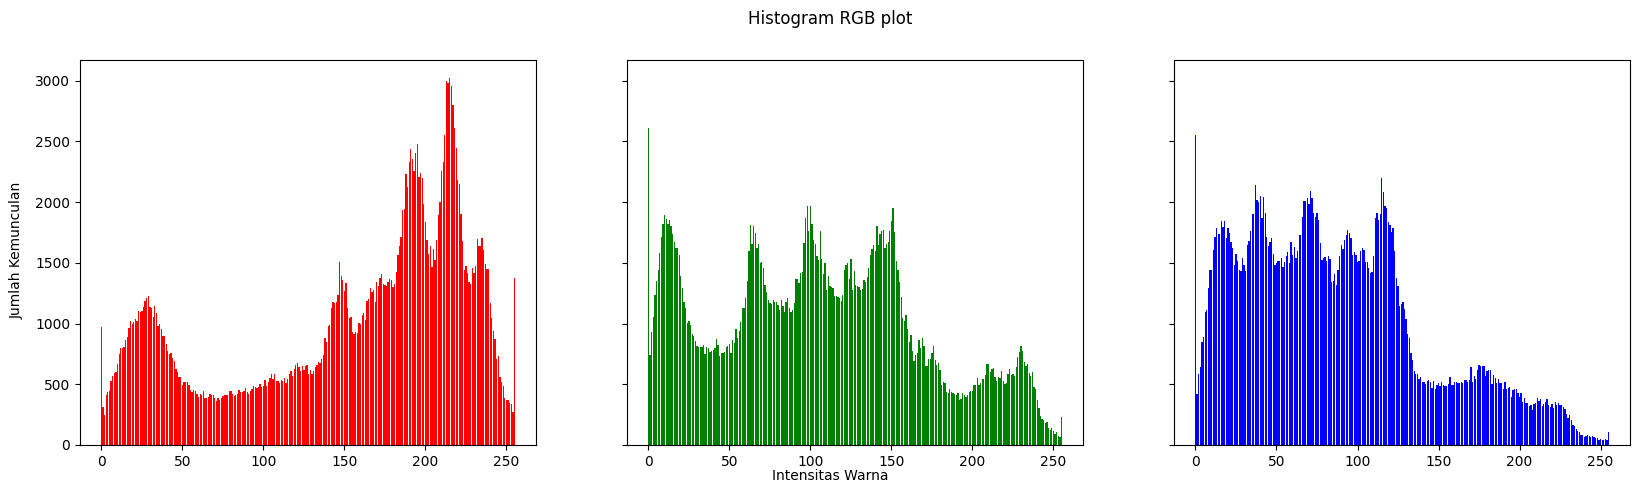

In [2]:
img = cv.imread('/content/drive/MyDrive/PCVK/lena pcvk.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height) :
  for x in range(0, width) :
    red[img[y] [x] [0]] += 1
    green[img[y] [x] [1]] += 1
    blue[img[y] [x] [2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

## Pertanyaan Praktikum E1
### 1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.

In [3]:
def histogram_manual(channel):
    h = [0] * 256
    for y in range(channel.shape[0]):
        for x in range(channel.shape[1]):
            h[channel[y][x]] += 1
    return np.array(h, dtype=np.int64)

def bandingkan_histogram(path, judul):
    print("=" * 55)
    print(f"HASIL UNTUK: {judul}")
    print(f"Path: {path}")
    print("=" * 55)

    img = cv.imread(path)
    if img is None:
        print(f"Gambar tidak ditemukan di {path}\n")
        return

    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    # Nama kanal sesuai urutan di citra RGB
    kanal_info = [
        ('Merah (R)', 0),
        ('Hijau (G)', 1),
        ('Biru  (B)', 2),
    ]

    for nama, idx in kanal_info:
        ch = img[:, :, idx]

        # 1: Manual (looping)
        h_manual = histogram_manual(ch)

        # 2: numpy.histogram
        h_numpy, _ = np.histogram(ch, bins=256, range=(0, 256))

        # 3: cv.calcHist
        h_cv = cv.calcHist([ch], [0], None, [256], [0, 256]).flatten()
        h_cv = h_cv.astype(np.int64)

        # Hitung selisih maksimum
        d1 = int(np.max(np.abs(h_manual - h_numpy)))
        d2 = int(np.max(np.abs(h_manual - h_cv)))
        d3 = int(np.max(np.abs(h_numpy  - h_cv)))

        print(f"\nKanal {nama}:")
        print(f"  Max |Manual - NumPy | = {d1}")
        print(f"  Max |Manual - cv   | = {d2}")
        print(f"  Max |NumPy  - cv   | = {d3}")
        print(f"  Total piksel  Manual={h_manual.sum()} | "
              f"NumPy={h_numpy.sum()} | cv={int(h_cv.sum())}")
        print(f"  Status: {'SAMA (selisih 0)' if (d1==0 and d2==0 and d3==0) else 'BEDA'}")

    print()

# 1: lena.jpg
bandingkan_histogram(
    '/content/drive/MyDrive/PCVK/lena pcvk.jpg',
    'Lena.jpg (#1)'
)

# TAHAP 2: KTM.jpg
bandingkan_histogram(
    '/content/drive/MyDrive/PCVK/Ktm bima.jpg',
    'Ktm bima.jpg (#2)'
)

HASIL UNTUK: Lena.jpg (#1)
Path: /content/drive/MyDrive/PCVK/lena pcvk.jpg

Kanal Merah (R):
  Max |Manual - NumPy | = 0
  Max |Manual - cv   | = 0
  Max |NumPy  - cv   | = 0
  Total piksel  Manual=262144 | NumPy=262144 | cv=262144
  Status: SAMA (selisih 0)

Kanal Hijau (G):
  Max |Manual - NumPy | = 0
  Max |Manual - cv   | = 0
  Max |NumPy  - cv   | = 0
  Total piksel  Manual=262144 | NumPy=262144 | cv=262144
  Status: SAMA (selisih 0)

Kanal Biru  (B):
  Max |Manual - NumPy | = 0
  Max |Manual - cv   | = 0
  Max |NumPy  - cv   | = 0
  Total piksel  Manual=262144 | NumPy=262144 | cv=262144
  Status: SAMA (selisih 0)

HASIL UNTUK: Ktm bima.jpg (#2)
Path: /content/drive/MyDrive/PCVK/Ktm bima.jpg

Kanal Merah (R):
  Max |Manual - NumPy | = 0
  Max |Manual - cv   | = 0
  Max |NumPy  - cv   | = 0
  Total piksel  Manual=3656723 | NumPy=3656723 | cv=3656723
  Status: SAMA (selisih 0)

Kanal Hijau (G):
  Max |Manual - NumPy | = 0
  Max |Manual - cv   | = 0
  Max |NumPy  - cv   | = 0
  Total

### 2. Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi pencahayaan saat akuisisi pada Pertemuan 2

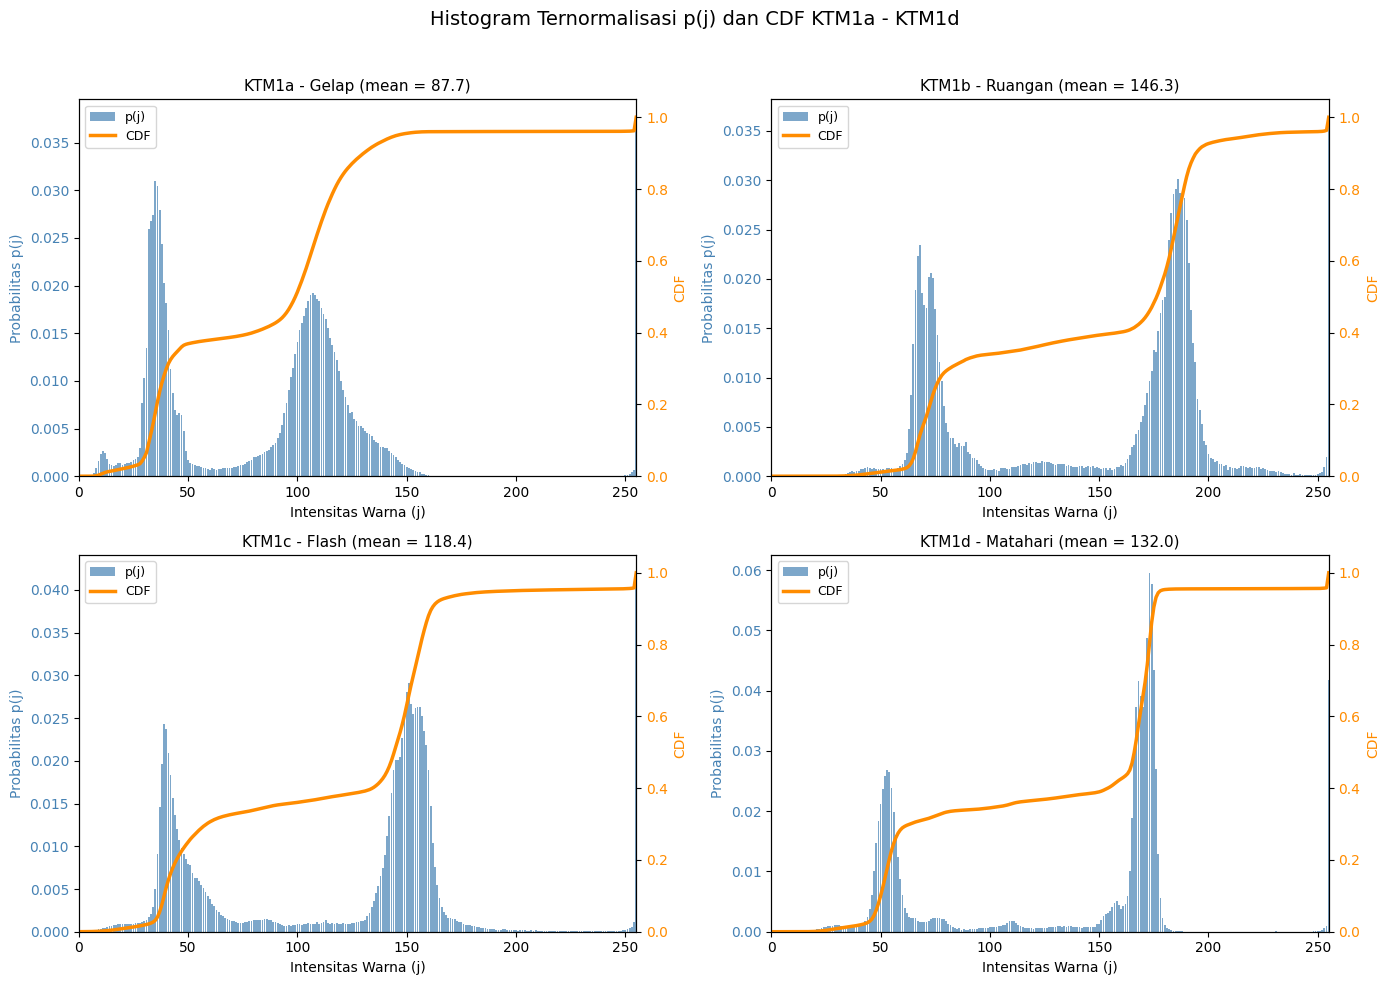

In [4]:
daftar_ktm = [
    ('KTM1a.jpg', 'KTM1a - Gelap'),
    ('KTM1b.jpg', 'KTM1b - Ruangan'),
    ('KTM1c.jpg', 'KTM1c - Flash'),
    ('KTM1d.jpg', 'KTM1d - Matahari'),
]

BASE = '/content/drive/MyDrive/PCVK/'

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Histogram Ternormalisasi p(j) dan CDF KTM1a - KTM1d', fontsize=14)

for ax, (nama_file, judul) in zip(axs.flat, daftar_ktm):
    img = cv.imread(BASE + nama_file, cv.IMREAD_GRAYSCALE)

    if img is None:
        ax.set_title(judul + ' - tidak ditemukan')
        ax.axis('off')
        continue

    # histogram manual
    h = np.zeros(256, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1

    # normalisasi p(j) dan hitung CDF
    p = h / img.size
    cdf = np.cumsum(p)

    # plot p(j) di sumbu kiri
    ax.bar(np.arange(256), p, color='steelblue', alpha=0.7, label='p(j)')
    ax.set_xlabel('Intensitas Warna (j)')
    ax.set_ylabel('Probabilitas p(j)', color='steelblue')
    ax.tick_params(axis='y', labelcolor='steelblue')
    ax.set_xlim([0, 255])

    # plot CDF di sumbu kanan
    ax2 = ax.twinx()
    ax2.plot(np.arange(256), cdf, color='darkorange', linewidth=2.5, label='CDF')
    ax2.set_ylabel('CDF', color='darkorange')
    ax2.tick_params(axis='y', labelcolor='darkorange')
    ax2.set_ylim([0, 1.05])

    ax.set_title(judul + ' (mean = ' + str(round(img.mean(), 1)) + ')', fontsize=11)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 3. Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan 256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang ketika jumlah bin dikurangi.

In [5]:
NAMA = 'Muhammad Bima Juliansyah'
NIM = '244107020123'

N = int(NIM[-3:])

PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2 ** ((N % 3) + 1),
}

print('NAMA :', NAMA)
print('NIM  :', NIM, '| N =', N)
for k, v in PARAM.items():
    print(k, ':', v)

NAMA : Muhammad Bima Juliansyah
NIM  : 244107020123 | N = 123
bins : 64
clip : 2.5
tile : 5
L : 2


# E-2 PERCOBAAN HISTOGRAM EQUALIZATION
## 1. Buatlah histogram equalization beserta tampilan citra sebelum dan sesudah proses, berdasarkan flowchart di bawah ini. Tahap 1 gunakan citra contoh lena_lc.jpg dan cocokkan hasilnya dengan gambar contoh pada modul; tahap 2 ulangi pada citra KTM1a.jpg milik Anda, yaitu hasil akuisisi di ruangan gelap.

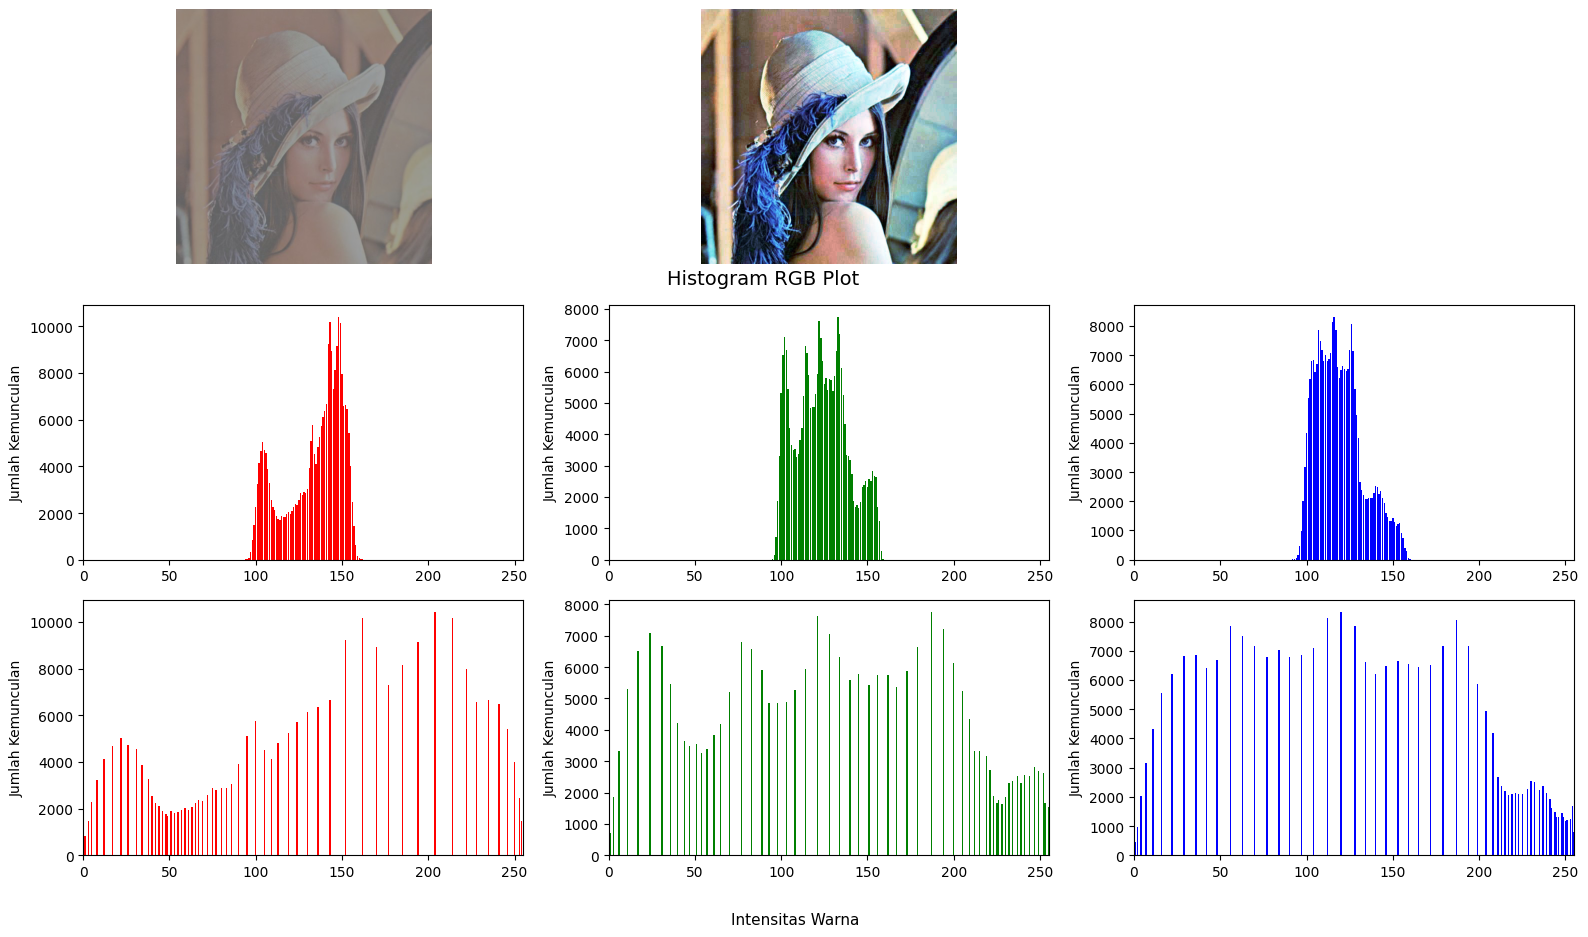

In [6]:
def he_manual(channel):
  h = np.zeros(256, dtype=np.int64)
  for i in range(channel.shape[0]):
    for j in range(channel.shape[1]):
      h[channel[i,j]] += 1

  total = channel.size
  p = h/ total
  cdf = np.cumsum(p)
  s = np.round(255 * cdf).astype(np.uint8)
  return s[channel], h

img = cv.imread('/content/drive/MyDrive/PCVK/lena_lc.jpg')

r_he , h_r_asli = he_manual(img[:,:,2])
g_he , h_g_asli = he_manual(img[:,:,1])
b_he , h_b_asli = he_manual(img[:,:,0])

hasil = np.stack((b_he, g_he, r_he), axis=2)

h_r_hasil = np.zeros(256, dtype=np.int64)
h_g_hasil = np.zeros(256, dtype=np.int64)
h_b_hasil = np.zeros(256, dtype=np.int64)

for i in range(hasil.shape[0]):
  for j in range(hasil.shape[1]):
    h_b_hasil[hasil[i,j,0]] += 1
    h_g_hasil[hasil[i,j,1]] += 1
    h_r_hasil[hasil[i,j,2]] += 1

fig = plt.figure(figsize=(16,10))

ax_img1 = fig.add_subplot(3,3,1)
ax_img1.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
ax_img1.axis('off')

ax_img2 = fig.add_subplot(3,3,2)
ax_img2.imshow(cv.cvtColor(hasil, cv.COLOR_BGR2RGB))
ax_img2.axis('off')

ax_img3 = fig.add_subplot(3,3,3)
ax_img3.axis('off')

warna = ['red', 'green', 'blue']
h_asli = [h_r_asli, h_g_asli, h_b_asli]
h_hasil = [h_r_hasil, h_g_hasil, h_b_hasil]

for k in range(3):
  ax_a = fig.add_subplot(3,3,4+k)
  ax_a.bar(np.arange(256), h_asli[k], color=warna[k])
  ax_a.set_xlim([0,255])
  ax_a.set_ylabel('Jumlah Kemunculan')

  ax_b = fig.add_subplot(3,3,7+k)
  ax_b.bar(np.arange(256), h_hasil[k], color=warna[k])
  ax_b.set_xlim([0,255])
  ax_b.set_ylabel('Jumlah Kemunculan')

fig.text(0.42, 0.66, 'Histogram RGB Plot', fontsize=14)
fig.text(0.5, 0.02, 'Intensitas Warna', ha='center', fontsize=11)

plt.tight_layout(rect=[0,0.05,1, 0.95])
plt.show()

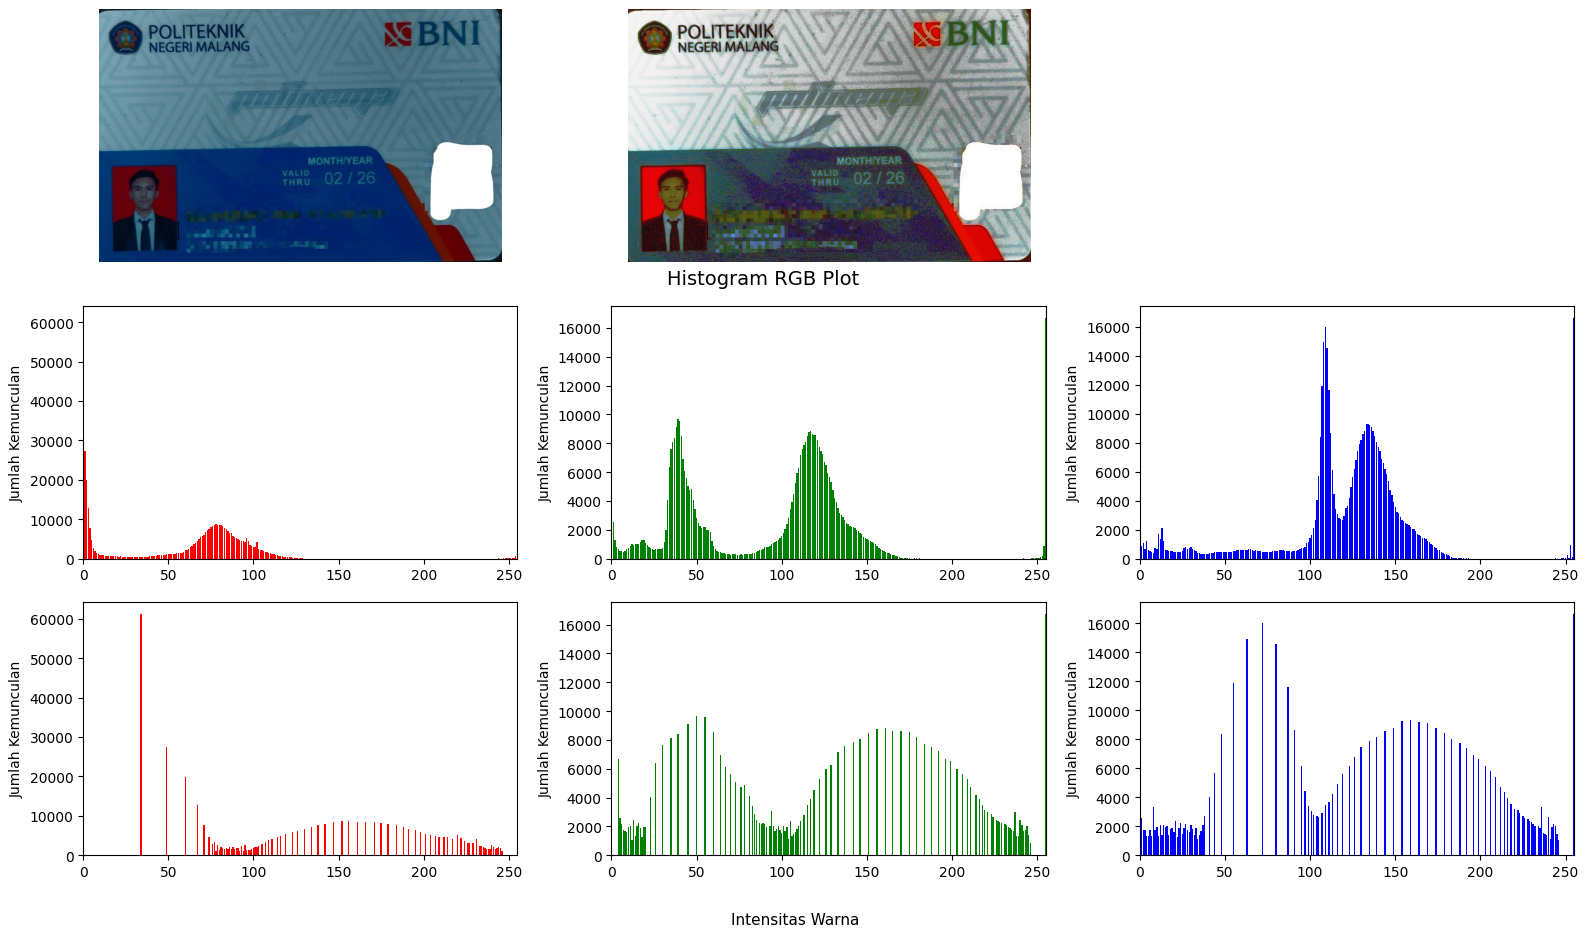

In [7]:
def he_manual(channel):
  h = np.zeros(256, dtype=np.int64)
  for i in range(channel.shape[0]):
    for j in range(channel.shape[1]):
      h[channel[i,j]] += 1

  total = channel.size
  p = h/ total
  cdf = np.cumsum(p)
  s = np.round(255 * cdf).astype(np.uint8)
  return s[channel], h

img = cv.imread('/content/drive/MyDrive/PCVK/KTM1a.jpg')

r_he , h_r_asli = he_manual(img[:,:,2])
g_he , h_g_asli = he_manual(img[:,:,1])
b_he , h_b_asli = he_manual(img[:,:,0])

hasil = np.stack((b_he, g_he, r_he), axis=2)

h_r_hasil = np.zeros(256, dtype=np.int64)
h_g_hasil = np.zeros(256, dtype=np.int64)
h_b_hasil = np.zeros(256, dtype=np.int64)

for i in range(hasil.shape[0]):
  for j in range(hasil.shape[1]):
    h_b_hasil[hasil[i,j,0]] += 1
    h_g_hasil[hasil[i,j,1]] += 1
    h_r_hasil[hasil[i,j,2]] += 1

fig = plt.figure(figsize=(16,10))

ax_img1 = fig.add_subplot(3,3,1)
ax_img1.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
ax_img1.axis('off')

ax_img2 = fig.add_subplot(3,3,2)
ax_img2.imshow(cv.cvtColor(hasil, cv.COLOR_BGR2RGB))
ax_img2.axis('off')

ax_img3 = fig.add_subplot(3,3,3)
ax_img3.axis('off')

warna = ['red', 'green', 'blue']
h_asli = [h_r_asli, h_g_asli, h_b_asli]
h_hasil = [h_r_hasil, h_g_hasil, h_b_hasil]

for k in range(3):
  ax_a = fig.add_subplot(3,3,4+k)
  ax_a.bar(np.arange(256), h_asli[k], color=warna[k])
  ax_a.set_xlim([0,255])
  ax_a.set_ylabel('Jumlah Kemunculan')

  ax_b = fig.add_subplot(3,3,7+k)
  ax_b.bar(np.arange(256), h_hasil[k], color=warna[k])
  ax_b.set_xlim([0,255])
  ax_b.set_ylabel('Jumlah Kemunculan')

fig.text(0.42, 0.66, 'Histogram RGB Plot', fontsize=14)
fig.text(0.5, 0.02, 'Intensitas Warna', ha='center', fontsize=11)

plt.tight_layout(rect=[0,0.05,1, 0.95])
plt.show()

## 2. Lengkapi potongan kode tersebut. Bandingkan hasil equalizeHist dengan hasil implementasi manual Anda dengan menghitung selisih maksimum antara keduanya, baik pada lena_lc.jpg maupun pada KTM1a.jpg, lalu jelaskan penyebab selisih tersebut apabila tidak nol

### Step 1

lena_lc.jpg
Selisih max kanal B: 0
Selisih max kanal G: 0
Selisih max kanal R: 0


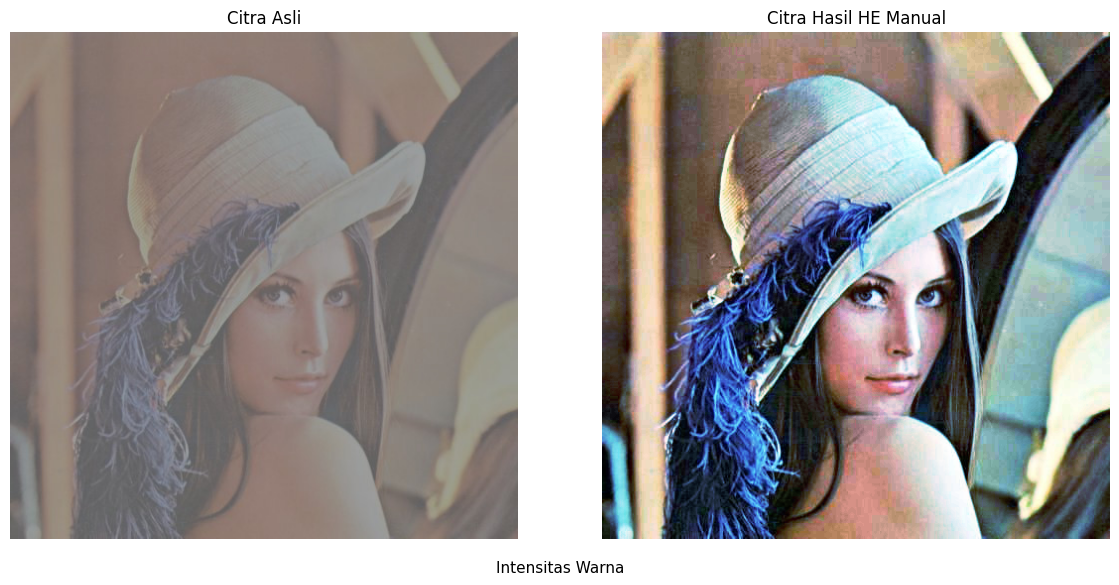

In [8]:
def he_manual(channel):
    h = np.zeros(256, dtype=np.int64)
    for i in range(channel.shape[0]):
        for j in range(channel.shape[1]):
            h[channel[i,j]] += 1

    total = channel.size
    p = h / total
    cdf = np.cumsum(p)
    s = np.round(255 * cdf).astype(np.uint8)
    return s[channel]

img = cv.imread('/content/drive/MyDrive/PCVK/lena_lc.jpg')

b, g, r = cv.split(img)

# Menjalankan fungsi manual
b_manual = he_manual(b)
g_manual = he_manual(g)
r_manual = he_manual(r)

b_eq = cv.equalizeHist(b)
g_eq = cv.equalizeHist(g)
r_eq = cv.equalizeHist(r)

print('lena_lc.jpg')
print('Selisih max kanal B:', np.max(np.abs(b_manual.astype(np.int16) - b_eq.astype(np.int16))))
print('Selisih max kanal G:', np.max(np.abs(g_manual.astype(np.int16) - g_eq.astype(np.int16))))
print('Selisih max kanal R:', np.max(np.abs(r_manual.astype(np.int16) - r_eq.astype(np.int16))))

hasil = np.stack([b_manual, g_manual, r_manual], axis=2)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
axs[0].axis('off')
axs[0].set_title('Citra Asli')

axs[1].imshow(cv.cvtColor(hasil, cv.COLOR_BGR2RGB))
axs[1].axis('off')
axs[1].set_title('Citra Hasil HE Manual')

fig.text(0.5, 0.02, 'Intensitas Warna', ha='center', fontsize=11)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

### Step 2

lena_lc.jpg
Selisih max kanal B: 1
Selisih max kanal G: 4
Selisih max kanal R: 34


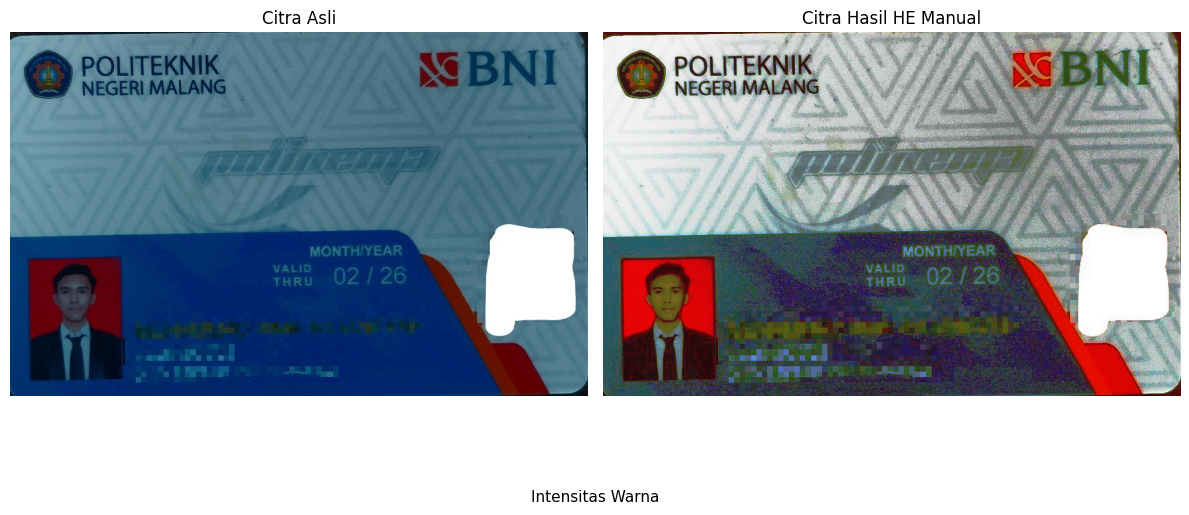

In [10]:
def he_manual(channel):
    h = np.zeros(256, dtype=np.int64)
    for i in range(channel.shape[0]):
        for j in range(channel.shape[1]):
            h[channel[i,j]] += 1

    total = channel.size
    p = h / total
    cdf = np.cumsum(p)
    s = np.round(255 * cdf).astype(np.uint8)
    return s[channel]

img = cv.imread('/content/drive/MyDrive/PCVK/KTM1a.jpg')

b, g, r = cv.split(img)

# Menjalankan fungsi manual
b_manual = he_manual(b)
g_manual = he_manual(g)
r_manual = he_manual(r)

b_eq = cv.equalizeHist(b)
g_eq = cv.equalizeHist(g)
r_eq = cv.equalizeHist(r)

print('lena_lc.jpg')
print('Selisih max kanal B:', np.max(np.abs(b_manual.astype(np.int16) - b_eq.astype(np.int16))))
print('Selisih max kanal G:', np.max(np.abs(g_manual.astype(np.int16) - g_eq.astype(np.int16))))
print('Selisih max kanal R:', np.max(np.abs(r_manual.astype(np.int16) - r_eq.astype(np.int16))))

hasil = np.stack([b_manual, g_manual, r_manual], axis=2)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
axs[0].axis('off')
axs[0].set_title('Citra Asli')

axs[1].imshow(cv.cvtColor(hasil, cv.COLOR_BGR2RGB))
axs[1].axis('off')
axs[1].set_title('Citra Hasil HE Manual')

fig.text(0.5, 0.02, 'Intensitas Warna', ha='center', fontsize=11)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

## 3. Ekualisasi juga dapat diterapkan pada citra berwarna. Cara yang biasanya pertama kali terpikirkan adalah mengekualisasi kanal biru, hijau, dan merah satu per satu. Jalankan potongan kode berikut pada citra contoh lena.jpg terlebih dulu, kemudian ulangi pada KTM1d.jpg milik Anda, dan amati warna yang dihasilkan pada keduanya.

### Step 1: Lena

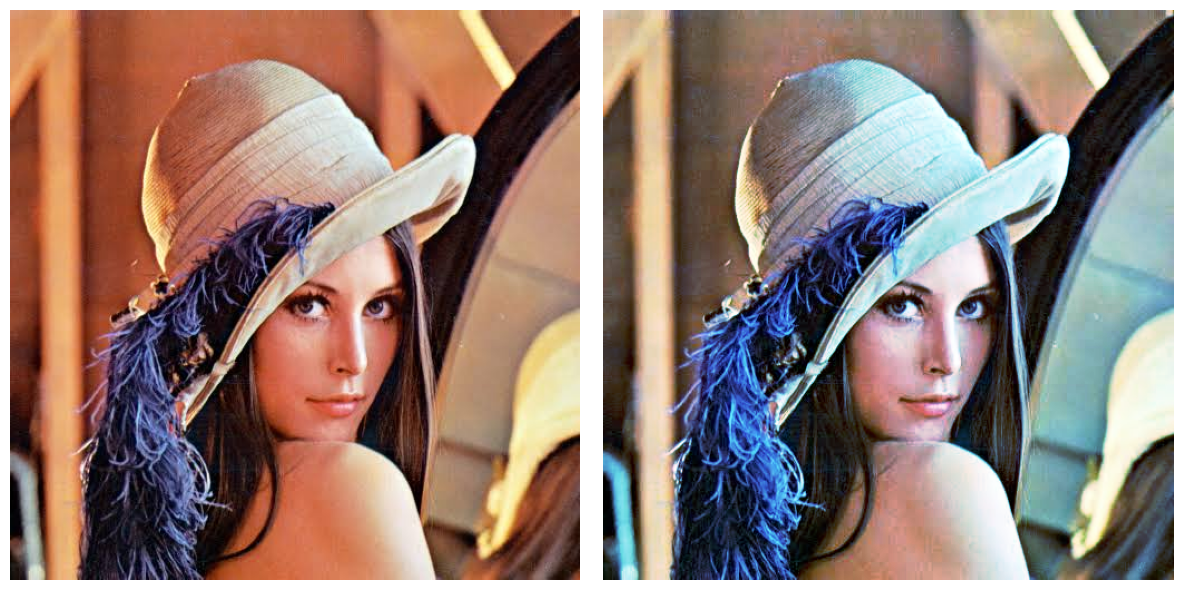

In [11]:
thefile = '/content/drive/MyDrive/PCVK/lena pcvk.jpg'

bgr = cv.imread(thefile)

kanal = list(cv.split(bgr))

for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])

he_rgb = cv.merge(kanal)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
axs[0].axis('off')

axs[1].imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB))
axs[1].axis('off')

plt.tight_layout()
plt.show()

### Step 2: KTMid

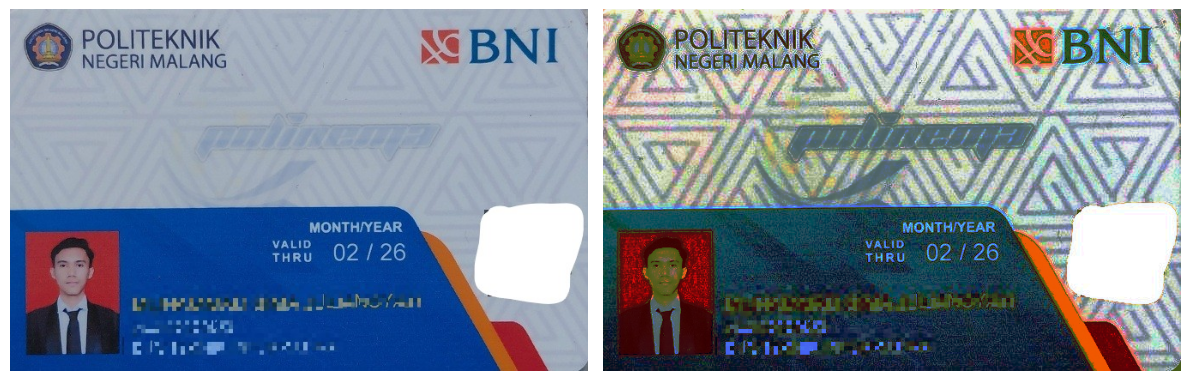

In [15]:
thefile = '/content/drive/MyDrive/PCVK/KTM1d.jpg'

bgr = cv.imread(thefile)

kanal = list(cv.split(bgr))

for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])

he_rgb = cv.merge(kanal)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
axs[0].axis('off')

axs[1].imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB))
axs[1].axis('off')

plt.tight_layout()
plt.show()


## 4. Cara kedua memisahkan kecerahan dari informasi warna. Citra diubah ke ruang warna YCrCb, hanya kanal Y yang diekualisasi, lalu dikembalikan ke BGR. Kanal Cr dan Cb yang menyimpan informasi warna tidak disentuh sama sekali. Kanal V pada HSV dan kanal L pada LAB berperan serupa, sehingga ketiganya dicoba sekaligus. (gunakan KTM1d.jpg)

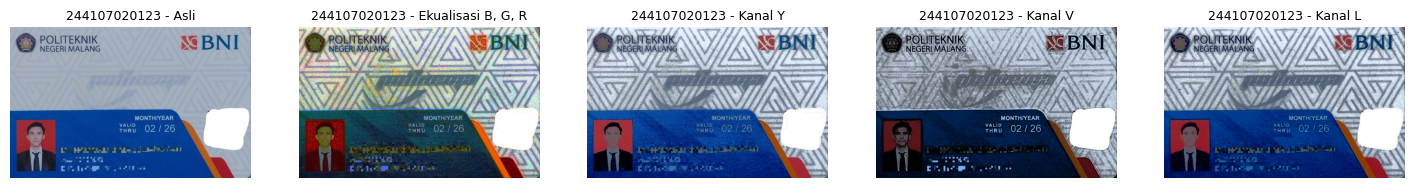

In [16]:
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]
plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')
plt.show()

In [17]:
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)
    return d.mean()

print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
    print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2, cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            132.0
Ekualisasi B, G, R                53.38            128.4
Kanal Y                            1.29            132.2
Kanal V                            1.10            110.1
Kanal L                            3.02            124.0
